# 3 - E-commerce Product Review Classification - Deep Learning

<img src='https://www.servcorp.co.uk/media/34561/e-commerce-img.jpeg'>

Bu çalışmada e-ticaret ürün yorumlarındaki duygu etiketlerini tahmin etmek için LSTM tabanlı bir deep learning modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Tokenization ve sequence hazırlama
6. LSTM modeli kurma
7. Tahmin
8. Sonuç


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


## 1. Veriyi Yükleme

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Amazon Customer Reviews with Sentiment.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config',
 'Amazon Review Data Web Scrapping - Amazon Review Data Web Scrapping.csv',
 'drive',
 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [4]:
# Bu bölümde csv dosyasını okuyup veri setinin genel yapısını inceleyeceğim.

In [5]:
df = pd.read_csv('/content/Amazon Review Data Web Scrapping - Amazon Review Data Web Scrapping.csv')
df.head()


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral


In [6]:
df.shape


(60889, 6)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60889 entries, 0 to 60888
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unique_ID      60889 non-null  int64 
 1   Category       60889 non-null  object
 2   Review_Header  60884 non-null  object
 3   Review_text    60857 non-null  object
 4   Rating         60889 non-null  int64 
 5   Own_Rating     60889 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.8+ MB


In [8]:
df['Own_Rating'].value_counts()


,count
Own_Rating,
Positive,47436
Negative,9087
Neutral,4366


## 3. Veri Temizleme

In [9]:
# Bu bölümde boş yorumları temizleyip metin sütununu string tipine dönüştüreceğim.

In [10]:
df = df.dropna(subset=['Review_text', 'Own_Rating'])
df['Review_text'] = df['Review_text'].astype(str)
df['Own_Rating'] = df['Own_Rating'].astype(str)
df.head()


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral


## 4. Feature Engineering

In [11]:
# Bu bölümde etiketleri sayısal forma çevirip eğitim ve test verisini ayıracağım.

In [12]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['Own_Rating'])

x_train, x_test, y_train, y_test = train_test_split(
    df['Review_text'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

x_train.shape, x_test.shape


((48685,), (12172,))

## 5. Tokenization ve Sequence Hazırlama

In [13]:
# Bu bölümde metinleri tokenlara ayırıp LSTM için sabit uzunlukta sequence haline getireceğim.

In [14]:
max_words = 15000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

x_train_pad.shape, x_test_pad.shape


((48685, 150), (12172, 150))

## 6. LSTM Modeli Kurma

In [15]:
# Bu bölümde Embedding ve Bidirectional LSTM katmanlarını kullanarak deep learning modelini kurup eğiteceğim.

In [16]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train_pad, y_train_cat, epochs=15, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.8535 - loss: 0.4309 - val_accuracy: 0.8661 - val_loss: 0.3833
Epoch 2/15
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.8825 - loss: 0.3384 - val_accuracy: 0.8722 - val_loss: 0.3885
Epoch 3/15
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8942 - loss: 0.2979 - val_accuracy: 0.8692 - val_loss: 0.3943
Epoch 4/15
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.9060 - loss: 0.2663 - val_accuracy: 0.8632 - val_loss: 0.4201


## 7. Tahmin

In [17]:
# Bu bölümde test verisi üzerinde tahmin yapıp accuracy ve F1 score ile değerlendireceğim.

In [18]:
y_pred_probs = model.predict(x_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print('Accuracy:', round(accuracy, 4))
print('F1 Score:', round(f1, 4))


381/381 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Accuracy: 0.8661
F1 Score: 0.8361


In [19]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

    Negative       0.66      0.82      0.73      1817
     Neutral       0.00      0.00      0.00       873
    Positive       0.91      0.96      0.93      9482

    accuracy                           0.87     12172
   macro avg       0.52      0.59      0.55     12172
weighted avg       0.81      0.87      0.84     12172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


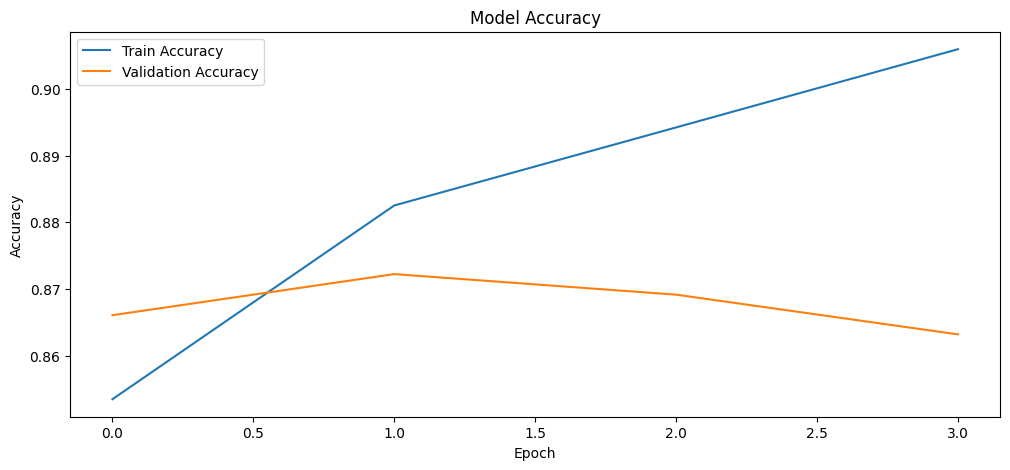

In [20]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 8. Sonuç

Bu projede e-ticaret ürün yorumlarındaki duygu etiketlerini tahmin etmek için LSTM tabanlı bir deep learning modeli kullanıldı. Elde edilen sonuçlara göre model test verisi üzerinde yorum sınıflarını tahmin etti ve 0.8661 accuracy ile 0.8361 F1 score değeri elde etti.
